<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment No. 2
## Linear Regression, Non-Linear Regression & Curve Fitting

---

###  Aim
To implement **Linear Regression** and **Non-Linear Regression** from scratch using NumPy, apply **curve fitting** for both types, and evaluate model performance using error correction methods — **MSE (Mean Squared Error)** and **MAE (Mean Absolute Error)**.

---

###  Theory

####  What is Regression?
Regression is a **supervised learning** technique used to predict a **continuous output** value based on one or more input features.

The goal is to find the best-fitting mathematical function that maps inputs (X) to outputs (y).

---

####  Linear Regression
Linear Regression assumes the relationship between input and output is a **straight line**:

**ŷ = w·x + b**

- **w** = weight (slope)
- **b** = bias (intercept)

We minimize the cost using **Gradient Descent**.

---

####  Non-Linear Regression
When data follows a **curved pattern**, a straight line cannot model it well. We instead fit a **polynomial** or other non-linear function.

For a **Polynomial of degree d**:

**ŷ = w₀ + w₁·x + w₂·x² + w₃·x³ + ... + wₐ·xᵈ**

We can still use **linear algebra (Normal Equation)** to solve this by treating each power of x as a separate feature — this is called **Polynomial Feature Expansion**.

**Normal Equation:**
**W = (XᵀX)⁻¹ · Xᵀ · y**

This gives us the optimal weights directly without gradient descent.

---

####  Curve Fitting
Curve fitting is the process of finding the **mathematical curve** (line or polynomial) that best passes through a set of data points by minimizing the error.

---

####  Error Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **MSE** | (1/m) · Σ(ŷ - y)² | Penalizes large errors more (squared) |
| **MAE** | (1/m) · Σ\|ŷ - y\| | Average absolute error, more interpretable |

Lower values of MSE and MAE = better model fit.

In [ ]:
# Import required libraries
import numpy as np          # For numerical operations and matrix math
import pandas as pd         # For organizing data in tabular form
import matplotlib.pyplot as plt  # For plotting graphs

print("Libraries imported successfully!")

Libraries imported successfully!


---
##  Part A: Linear Regression with Gradient Descent

We generate data with a true linear relationship:
**y = 2x + 5 + noise**

The model should learn w ≈ 2, b ≈ 5.

In [ ]:
# Set seed for reproducibility
np.random.seed(0)

# Number of data points
m = 100

# Input feature: 100 evenly spaced values from 0 to 10
x = np.linspace(0, 10, m)

# True relationship: y = 2x + 5 + noise
noise = np.random.randn(m) * 1.5
y_linear = 2 * x + 5 + noise

# Display in DataFrame
df_linear = pd.DataFrame({"x": x, "y": y_linear})
print("Linear Dataset (first 5 rows):")
print(df_linear.head())

Linear Dataset (first 5 rows):
         x         y
0  0.00000  7.646079
1  0.10101  5.802256
2  0.20202  6.872147
3  0.30303  8.967400
4  0.40404  8.609418


In [ ]:
# Shuffle and split: 80% train, 20% test
df_linear = df_linear.sample(frac=1, random_state=0).reset_index(drop=True)

split = int(0.8 * m)

X_train_l = df_linear["x"].values[:split]
y_train_l = df_linear["y"].values[:split]

X_test_l = df_linear["x"].values[split:]
y_test_l = df_linear["y"].values[split:]

print("Train size:", len(X_train_l))
print("Test size :", len(X_test_l))

Train size: 80
Test size : 20


In [ ]:
# Initialize parameters
w = 0.0
b = 0.0

# Hyperparameters
alpha  = 0.01   # learning rate
epochs = 1000   # max iterations
tol    = 1e-6   # early stopping tolerance

m_train = len(X_train_l)
cost_history_linear = []

for i in range(epochs):

    # Forward pass: compute predictions
    y_pred = w * X_train_l + b

    # Compute MSE cost
    J = (1 / m_train) * np.sum((y_pred - y_train_l) ** 2)
    cost_history_linear.append(J)

    # Compute gradients
    dw = (2 / m_train) * np.sum((y_pred - y_train_l) * X_train_l)
    db = (2 / m_train) * np.sum(y_pred - y_train_l)

    # Update parameters
    w = w - alpha * dw
    b = b - alpha * db

    # Early stopping
    if i > 0 and abs(cost_history_linear[i] - cost_history_linear[i-1]) < tol:
        print(f"Converged at epoch {i}")
        break

    if i % 200 == 0:
        print(f"Epoch {i:4d} | Cost = {J:.4f} | w = {w:.4f} | b = {b:.4f}")

print(f"\nLearned: w = {w:.4f} (True = 2) | b = {b:.4f} (True = 5)")

Epoch    0 | Cost = 259.0089 | w = 1.8091 | b = 0.2980
Epoch  200 | Cost = 3.1994 | w = 2.2210 | b = 3.5899
Epoch  400 | Cost = 2.5305 | w = 2.0573 | b = 4.6798
Epoch  600 | Cost = 2.4509 | w = 2.0009 | b = 5.0559
Epoch  800 | Cost = 2.4414 | w = 1.9814 | b = 5.1856

Learned: w = 1.9747 (True = 2) | b = 5.2303 (True = 5)


In [ ]:
# Predict on test set
y_pred_test_l = w * X_test_l + b

# MSE
MSE_linear = np.mean((y_pred_test_l - y_test_l) ** 2)

# MAE
MAE_linear = np.mean(np.abs(y_pred_test_l - y_test_l))

print("=== Linear Regression — Test Set Errors ===")
print(f"  MSE = {MSE_linear:.4f}")
print(f"  MAE = {MAE_linear:.4f}")

=== Linear Regression — Test Set Errors ===
  MSE = 1.5993
  MAE = 1.0770


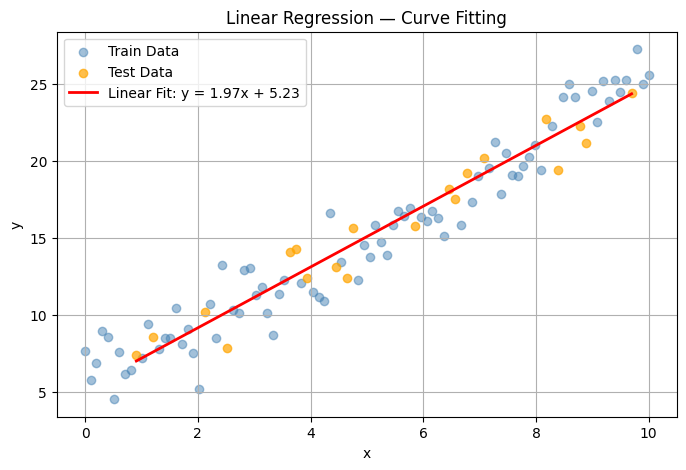

In [ ]:
# Sort test points for a clean line plot
sort_idx = np.argsort(X_test_l)
x_sorted = X_test_l[sort_idx]
y_sorted = y_pred_test_l[sort_idx]

plt.figure(figsize=(8, 5))

# Training data
plt.scatter(X_train_l, y_train_l, color='steelblue', alpha=0.5, label='Train Data')

# Test data
plt.scatter(X_test_l, y_test_l, color='orange', alpha=0.7, label='Test Data')

# Fitted regression line
plt.plot(x_sorted, y_sorted, color='red', linewidth=2,
         label=f'Linear Fit: y = {w:.2f}x + {b:.2f}')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression — Curve Fitting")
plt.legend()
plt.grid(True)
plt.show()

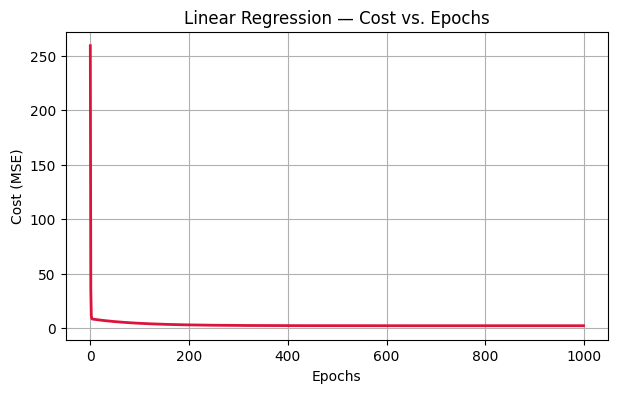

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(cost_history_linear, color='crimson', linewidth=2)
plt.xlabel("Epochs")
plt.ylabel("Cost (MSE)")
plt.title("Linear Regression — Cost vs. Epochs")
plt.grid(True)
plt.show()

---
##  Part B: Non-Linear Regression (Polynomial Curve Fitting)

Sometimes data follows a **curved** pattern that a straight line cannot capture.

We generate data with a true **quadratic (degree-2 polynomial)** relationship:
**y = 0.5·x² - 3·x + 10 + noise**

We will fit a polynomial using the **Normal Equation** — a closed-form (direct) solution.

####  Polynomial Feature Expansion
For degree d, we transform input x into a feature matrix:

**X_poly = [1, x, x², x³, ..., xᵈ]**

Each column is a new feature. The Normal Equation then finds the best weights directly:

**W = (XᵀX)⁻¹ · Xᵀ · y**

No gradient descent needed — we solve it in one step!

In [ ]:
# Set seed
np.random.seed(1)

# Input feature
x_nl = np.linspace(0, 10, m)

# True relationship: y = 0.5*x^2 - 3*x + 10 + noise
noise_nl = np.random.randn(m) * 2
y_nonlinear = 0.5 * x_nl**2 - 3 * x_nl + 10 + noise_nl

# DataFrame
df_nonlinear = pd.DataFrame({"x": x_nl, "y": y_nonlinear})
print("Non-Linear Dataset (first 5 rows):")
print(df_nonlinear.head())

Non-Linear Dataset (first 5 rows):
         x          y
0  0.00000  13.248691
1  0.10101   8.478558
2  0.20202   8.358002
3  0.30303   6.990886
4  0.40404  10.600318


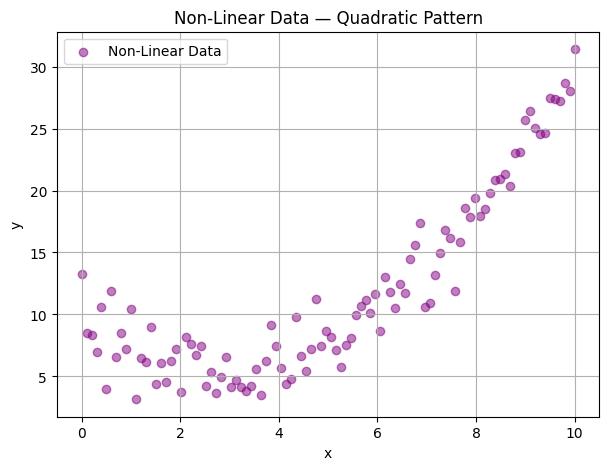

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(x_nl, y_nonlinear, color='purple', alpha=0.5, label='Non-Linear Data')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-Linear Data — Quadratic Pattern")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Shuffle and split
df_nonlinear = df_nonlinear.sample(frac=1, random_state=1).reset_index(drop=True)

X_train_nl = df_nonlinear["x"].values[:split]
y_train_nl = df_nonlinear["y"].values[:split]

X_test_nl = df_nonlinear["x"].values[split:]
y_test_nl = df_nonlinear["y"].values[split:]

print("Train size:", len(X_train_nl))
print("Test size :", len(X_test_nl))

Train size: 80
Test size : 20


---
###  Polynomial Feature Expansion

We manually create the feature matrix for degree-2 polynomial:

**X_poly = [x⁰, x¹, x²] = [1, x, x²]**

Each row corresponds to one data point. The Normal Equation then solves for **W = [w₀, w₁, w₂]** directly.

In [ ]:
def polynomial_features(x, degree):
    """
    Creates a polynomial feature matrix from input array x.
    For degree=2: returns columns [1, x, x^2]
    """
    # Stack columns: x^0, x^1, x^2, ..., x^degree
    return np.column_stack([x**d for d in range(degree + 1)])

# Choose polynomial degree
degree = 2

# Build feature matrices for train and test
X_poly_train = polynomial_features(X_train_nl, degree)
X_poly_test  = polynomial_features(X_test_nl,  degree)

print("Shape of X_poly_train:", X_poly_train.shape)
print("First 3 rows (columns = [x^0, x^1, x^2]):")
print(X_poly_train[:3])

# --- Normal Equation: W = (X'X)^-1 * X' * y ---
# np.linalg.pinv is used for numerical stability (pseudoinverse)
W_poly = np.linalg.pinv(X_poly_train.T @ X_poly_train) @ X_poly_train.T @ y_train_nl

print(f"\nLearned polynomial coefficients:")
print(f"  w0 (intercept) = {W_poly[0]:.4f}  (True ≈ 10)")
print(f"  w1 (x coeff)   = {W_poly[1]:.4f}  (True ≈ -3)")
print(f"  w2 (x² coeff)  = {W_poly[2]:.4f}  (True ≈ 0.5)")

Shape of X_poly_train: (80, 3)
First 3 rows (columns = [x^0, x^1, x^2]):
[[ 1.          8.08080808 65.29945924]
 [ 1.          8.48484848 71.99265381]
 [ 1.          3.33333333 11.11111111]]

Learned polynomial coefficients:
  w0 (intercept) = 10.1202  (True ≈ 10)
  w1 (x coeff)   = -2.9372  (True ≈ -3)
  w2 (x² coeff)  = 0.4960  (True ≈ 0.5)


In [ ]:
# Predict on test set using learned polynomial weights
y_pred_nl = X_poly_test @ W_poly

# MSE
MSE_nl = np.mean((y_pred_nl - y_test_nl) ** 2)

# MAE
MAE_nl = np.mean(np.abs(y_pred_nl - y_test_nl))

print("=== Non-Linear (Polynomial) Regression — Test Set Errors ===")
print(f"  MSE = {MSE_nl:.4f}")
print(f"  MAE = {MAE_nl:.4f}")

=== Non-Linear (Polynomial) Regression — Test Set Errors ===
  MSE = 4.4742
  MAE = 1.5304


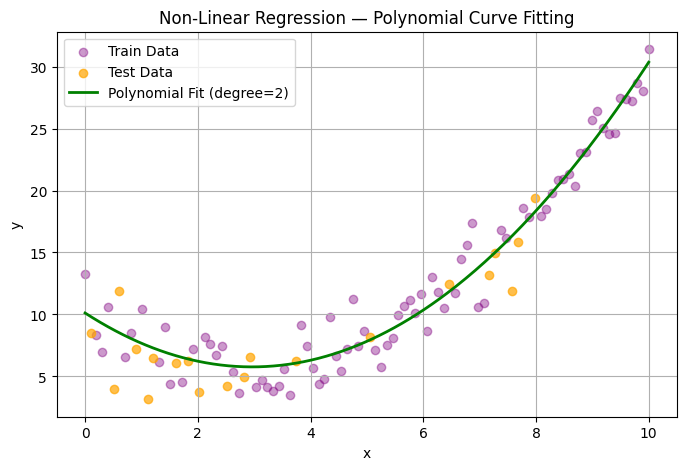

In [ ]:
# Generate smooth curve over the full x range for plotting
x_plot = np.linspace(0, 10, 300)
X_plot_poly = polynomial_features(x_plot, degree)
y_plot_curve = X_plot_poly @ W_poly

plt.figure(figsize=(8, 5))

# Training data
plt.scatter(X_train_nl, y_train_nl, color='purple', alpha=0.4, label='Train Data')

# Test data
plt.scatter(X_test_nl, y_test_nl, color='orange', alpha=0.7, label='Test Data')

# Fitted polynomial curve
plt.plot(x_plot, y_plot_curve, color='green', linewidth=2,
         label=f'Polynomial Fit (degree={degree})')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Non-Linear Regression — Polynomial Curve Fitting")
plt.legend()
plt.grid(True)
plt.show()

---
##  Part C: Effect of Polynomial Degree on Curve Fitting

A key question in Non-Linear Regression is: **which degree polynomial fits best?**

- **Too low degree (underfitting)** → model is too simple, misses the pattern
- **Too high degree (overfitting)** → model fits training data perfectly but fails on new data
- **Just right** → good balance between bias and variance

We will compare degree 1 (linear), 2 (quadratic), and 9 (very high) on the same data.

Degree  1 → Test MSE =  14.4260 | Test MAE =   3.0047
Degree  2 → Test MSE =   4.4742 | Test MAE =   1.5304
Degree  9 → Test MSE =  22.1556 | Test MAE =   3.6060


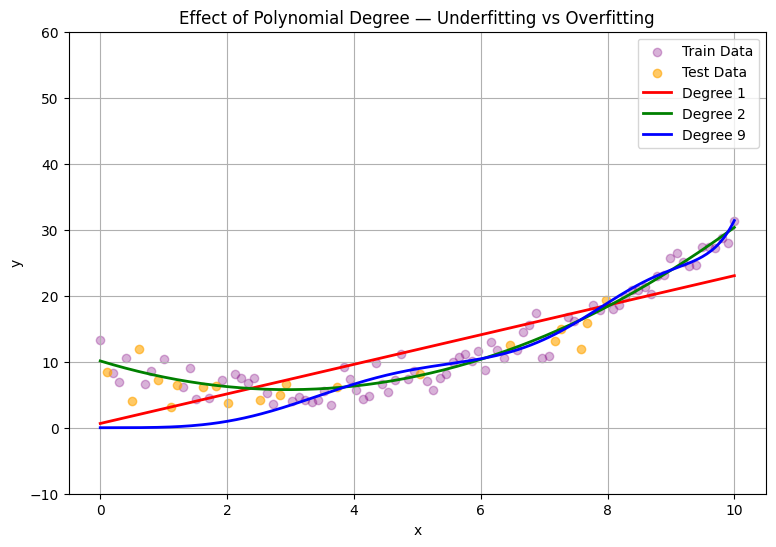

In [ ]:
degrees = [1, 2, 9]
colors  = ['red', 'green', 'blue']

# Smooth x range for plotting
x_plot = np.linspace(0, 10, 300)

plt.figure(figsize=(9, 6))
plt.scatter(X_train_nl, y_train_nl, color='purple', alpha=0.3, label='Train Data')
plt.scatter(X_test_nl,  y_test_nl,  color='orange', alpha=0.6, label='Test Data')

for deg, col in zip(degrees, colors):

    # Build features
    X_tr = polynomial_features(X_train_nl, deg)
    X_te = polynomial_features(X_test_nl,  deg)

    # Fit using Normal Equation
    W = np.linalg.pinv(X_tr.T @ X_tr) @ X_tr.T @ y_train_nl

    # Predict on test set
    y_te_pred = X_te @ W

    # Errors
    mse = np.mean((y_te_pred - y_test_nl) ** 2)
    mae = np.mean(np.abs(y_te_pred - y_test_nl))

    print(f"Degree {deg:2d} → Test MSE = {mse:8.4f} | Test MAE = {mae:8.4f}")

    # Plot smooth curve
    X_pl = polynomial_features(x_plot, deg)
    y_pl = X_pl @ W
    plt.plot(x_plot, y_pl, color=col, linewidth=2, label=f'Degree {deg}')

plt.ylim(-10, 60)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Effect of Polynomial Degree — Underfitting vs Overfitting")
plt.legend()
plt.grid(True)
plt.show()

---
##  Part D: Error Correction Methods — MSE vs MAE

Let's directly compare **MSE** and **MAE** side by side for Linear and Non-Linear models.

| Error Metric | Formula | Sensitivity to Outliers |
|---|---|---|
| **MSE** | mean of (ŷ - y)² | High — squares large errors |
| **MAE** | mean of \|ŷ - y\| | Low — treats all errors equally |

A model with **lower MSE but higher MAE** might be influenced by outliers.
We prefer to look at **both** together.

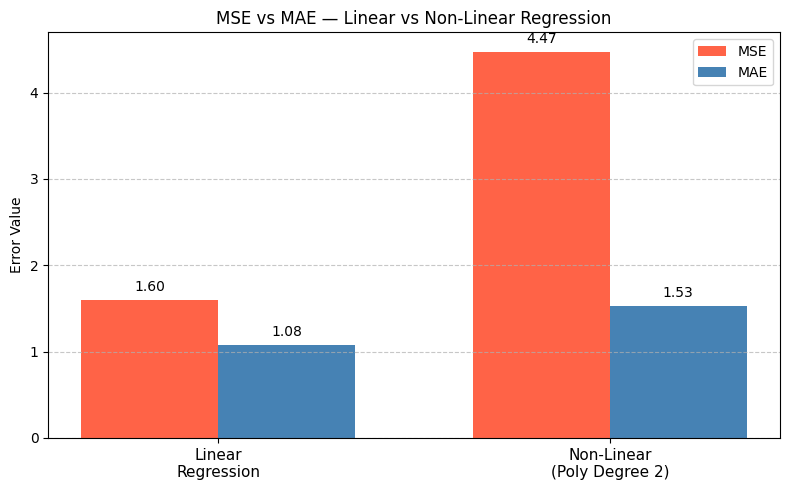

In [ ]:
# Collect errors for both models
models = ['Linear\nRegression', 'Non-Linear\n(Poly Degree 2)']
mse_vals = [MSE_linear, MSE_nl]
mae_vals = [MAE_linear, MAE_nl]

x_pos = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# MSE bars
bars1 = ax.bar(x_pos - width/2, mse_vals, width, label='MSE', color='tomato')

# MAE bars
bars2 = ax.bar(x_pos + width/2, mae_vals, width, label='MAE', color='steelblue')

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel("Error Value")
ax.set_title("MSE vs MAE — Linear vs Non-Linear Regression")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
###  Conclusion

In this experiment, we:

1. **Implemented Linear Regression** from scratch using Gradient Descent and performed curve fitting on linearly distributed data.

2. **Implemented Non-Linear (Polynomial) Regression** using the Normal Equation and polynomial feature expansion — fitting a quadratic curve to non-linear data.

3. **Compared polynomial degrees** (1, 2, 9) and observed:
   - **Degree 1** → Underfitting (too simple for curved data)
   - **Degree 2** → Best fit (matches the true pattern)
   - **Degree 9** → Overfitting (wiggles to fit training noise)

4. **Evaluated both models** using:
   - **MSE** — penalizes large errors more due to squaring
   - **MAE** — gives a more interpretable average error

**Key Insight:** Choosing the right model complexity and evaluating with multiple error metrics is essential for building reliable regression models.